In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.path.abspath('.')))
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import grad, jit, hessian
from optimizers import CR, ARC, AdaN, SuperUniversalNewton, Algorithm1,CubicMM,ECME
import numpy as np
import matplotlib.pyplot as plt
from models import (
    HighDimRosenbrock, PolytopeFeasibility, WorstInstancesFunction,
    ZakharovFunction, PowellSingularFunction, LogSumExpFunction,
    MultivariateTMLE
)
from optimizers import AdaN, ARC, CR, SuperUniversalNewton
class OptimizerTester:
    """优化器测试框架"""
    def __init__(self, optimizers=None, dim=200, n_runs=1, max_iter=300, tol=1e-8,
                 problem_type="rosenbrock", q_param=3, p_param=2, lse_n=500,
                 lse_rho=0.5, tmle_n_samples=1000, tmle_df_true=5.0):
        self.optimizers = optimizers or [
            ARC(),
            AdaN(),
            Algorithm1(alpha=1/2,beta=1/6),
            SuperUniversalNewton(),
            CR(),
            CubicMM(),
        ]
        self.dim = dim
        self.n_runs = n_runs
        self.max_iter = max_iter
        self.tol = tol
        self.problem_type = problem_type
        self.q_param = q_param
        self.p_param = p_param
        self.lse_n = lse_n
        self.lse_rho = lse_rho
        self.tmle_n_samples = tmle_n_samples
        self.tmle_df_true = tmle_df_true
        self.results = {}
        self.problem_names = {
            "rosenbrock": "Rosenbrock Function",
            "polytope": "Polytope Feasibility",
            "worst_instances": "Worst Instances Function",
            "zakharov": "Zakharov Function",
            "powell": "Powell Singular Function",
            "logsumexp": "Log-Sum-Exp Function",
            "tmle": "Multivariate t-MLE",  # 添加这一行
        }

    def _create_model(self):
        """根据问题类型创建模型"""
        if self.problem_type == "polytope":
            return PolytopeFeasibility(dim=self.dim, m=500, p=self.p_param)
        elif self.problem_type == "worst_instances":
            return WorstInstancesFunction(dim=self.dim, q=self.q_param)
        elif self.problem_type == "zakharov":
            return ZakharovFunction(dim=self.dim)
        elif self.problem_type == "powell":
            return PowellSingularFunction(dim=self.dim)
        elif self.problem_type == "logsumexp":
            return LogSumExpFunction(n=self.lse_n, d=self.dim, rho=self.lse_rho)
        elif self.problem_type == "tmle":  # 添加 t-MLE 问题
            return MultivariateTMLE(
                n_samples=self.tmle_n_samples,
                dim=self.dim,
                df_true=self.tmle_df_true,
                random_state=42
            )
        else:  # 默认Rosenbrock
            return HighDimRosenbrock(dim=self.dim)

    def _get_initial_theta(self, problem_type, run_idx):
        """根据问题类型获取初始点"""
        if problem_type == "polytope":
            # 多面体可行性问题，从原点开始
            return jnp.array(np.ones(self.dim) * 1)
        elif problem_type == "worst_instances":
            # Worst instances
            return jnp.array(np.ones(self.dim) * 1)
        elif problem_type == "zakharov":
            # Zakharov函数在原点有最小值，使用远离原点的初始点
            return jnp.array(np.ones(self.dim) * 1)
        elif problem_type == "powell":
            # Powell函数使用中等规模的初始点
            return jnp.array(np.ones(self.dim) * 1)
        elif problem_type == "logsumexp":
            # Powell函数使用中等规模的初始点
            return jnp.array(np.ones(self.dim) * 1)
        elif problem_type == "rosenbrock":  # Rosenbrock
            # Rosenbrock使用传统初始点
            return jnp.array(np.ones(self.dim) * 1.5)
        elif problem_type == "tmle":  # 添加 t-MLE 初始点
            # 使用 MultivariateTMLE 提供的初始猜测
            model = MultivariateTMLE(
                n_samples=self.tmle_n_samples,
                dim=self.dim,
                df_true=self.tmle_df_true,
                random_state=42
            )
            return model.get_initial_guess()

    def run_test(self, initial_theta_dict=None):
        """运行测试"""
        model = self._create_model()
        problem_name = self.problem_names.get(self.problem_type, "Rosenbrock Function")
        print(f"\nTesting on {problem_name} (dim={self.dim})")
        
        if initial_theta_dict is None:
            initial_theta_dict = {}
        
        for optimizer in self.optimizers:
            print(f"\nTesting {optimizer.name}...")
            self.results[optimizer.name] = []
            
            for run in range(self.n_runs):
                print(f"  Run {run + 1}/{self.n_runs}")
                
                # 获取初始点（优先使用自定义的）
                if self.problem_type in initial_theta_dict:
                    initial_theta = jnp.array(initial_theta_dict[self.problem_type])
                else:
                    initial_theta = self._get_initial_theta(self.problem_type, run)
                
                theta = optimizer.optimize(
                    model, self.dim,
                    initial_theta=initial_theta,
                    max_iter=self.max_iter
                )
                self.results[optimizer.name].append(optimizer.history.copy())
    
    def plot_results(self, time_range=None):
        """绘制结果 - 显示对数间隙距离
        Args:
            time_range: 时间范围 [min_time, max_time]，例如 [0, 10] 表示0-10秒
        """
        problem_name = self.problem_names.get(self.problem_type, "Rosenbrock Function")
        title = ""#f"{problem_name} (dim={self.dim}"
        #if self.problem_type == "worst_instances":
        #    title += f", q={self.q_param}"
        #elif self.problem_type == "polytope":
        #    title += f", p={self.p_param}"
        #title += ")"
        # 设置字体大小
        plt.rcParams.update({
            'font.size': 18,
            'axes.labelsize': 18,
            'xtick.labelsize': 16,
            'ytick.labelsize': 16,
            'legend.fontsize': 16,
            'axes.titlesize': 20,
        })
        # 获取问题的最优值（如果已知）
        optimal_values = {
            "rosenbrock": 0.0,           # Rosenbrock函数的最优值为0
            "zakharov": 0.0,             # Zakharov函数的最优值为0
            "worst_instances": 0.0,      # Worst instances函数的最优值为0
            "powell": 0.0,               # Powell函数的最优值为0
            "polytope": None,
            "logsumexp":None,
        }
        
        optimal_value = optimal_values.get(self.problem_type, 0.0)
        
        plt.figure(figsize=(16, 6))
        plt.suptitle(title, fontsize=14)
        
        # 定义线型样式
        styles = {
            'ARC': {'color': 'purple', 'linestyle': '--', 'linewidth': 2},
            'ALM': {'color': 'red', 'linestyle': '-', 'linewidth': 3},
            'SUN': {'color': 'green', 'linestyle': '--', 'linewidth': 2},
            'CR': {'color': 'black', 'linestyle': '--', 'linewidth': 2},
            'AdaN': {'color': 'orange', 'linestyle': '--', 'linewidth': 2},
            'CMM': {'color': 'brown', 'linestyle': '--',  'linewidth': 2},
            'ConvexCubicMM': {'color': 'black', 'linestyle': ':','linewidth': 6},
        }
    
        # 分别存储两个子图的收敛数据
        convergence_data_iter = {}  # 迭代次数的收敛数据
        convergence_data_time = {}  # 时间的收敛数据
        
        # 收集第一个子图的图例信息
        legend_handles_iter = []
        legend_labels_iter = []
        
        # 1. 对数间隙距离 vs 迭代
        plt.subplot(1, 2, 1)
        for name, runs in self.results.items():
            if not runs:
                continue
            
            # 找到最大迭代次数
            max_iterations = self.max_iter
            # 创建完整的间隙距离序列
            all_gaps = []
            all_times = []
            
            for run in runs:
                if run['loss'] and run['time']:
                    # 计算间隙距离：f(x) - f*
                    if optimal_value is not None:
                        gaps = [loss - optimal_value for loss in run['loss']]
                    else:
                        # 如果最优值未知，使用运行中的最小值作为参考
                        min_loss = min(run['loss'])
                        gaps = [loss - min_loss for loss in run['loss']]
                    
                    padded_gaps = gaps[:max_iterations]
                    padded_times = run['time'][:max_iterations]
                    
                    all_gaps.append(padded_gaps)
                    all_times.append(padded_times)
            
            if all_gaps:
                avg_gaps = np.mean(all_gaps, axis=0)
                avg_times = np.mean(all_times, axis=0)
                # 避免对数计算中的0或负值
                avg_gaps = np.maximum(avg_gaps, 1e-16)
                iterations = range(0,len(avg_gaps))
                line = plt.semilogy(iterations, avg_gaps, label=name, **styles.get(name, {}))[0]
                legend_handles_iter.append(line)
                legend_labels_iter.append(name)
                
                # 计算达到1e-12的迭代次数和时间
                convergence_iter = None
                convergence_time = None
                final_gap = avg_gaps[-1]  # 最终gap值
                
                for i, gap in enumerate(avg_gaps):
                    if gap <= 1e-12:
                        convergence_iter = i
                        if i < len(avg_times):
                            convergence_time = avg_times[i]
                        break
                
                # 如果没有达到收敛标准，使用最后一次迭代的数据
                if convergence_iter is None:
                    convergence_iter = len(avg_gaps) - 1
                    convergence_time = avg_times[-1]
                
                convergence_data_iter[name] = {
                    'iteration': convergence_iter,
                    'time': convergence_time,
                    'final_gap': final_gap,
                    'converged': convergence_iter < len(avg_gaps) - 1 or final_gap <= 1e-10
                }
        
        plt.xlabel('Iteration')
        plt.ylabel('Log Gap Distance: f(x) - f*')
        plt.grid(True, ls='-')
        plt.xlim(0, max_iterations)
        plt.ylim(bottom=1e-8)
        plt.title('Convergence vs Iterations')
        # 设置图例为两列
        plt.legend(handles=legend_handles_iter, labels=legend_labels_iter, ncol=2, 
                   loc='best', frameon=True, fancybox=True, shadow=True)
        
        # 2. 对数间隙距离 vs 时间（不显示y轴刻度，但保留网格线）
        plt.subplot(1, 2, 2)
        for name, runs in self.results.items():
            if not runs:
                continue
            
            # 收集所有有效的时间-间隙数据
            valid_traces = []
            
            for run in runs:
                if run['loss'] and run['time']:
                    # 计算间隙距离：f(x) - f*
                    if optimal_value is not None:
                        gaps = [loss - optimal_value for loss in run['loss']]
                    else:
                        # 如果最优值未知，使用运行中的最小值作为参考
                        min_loss = min(run['loss'])
                        gaps = [loss - min_loss for loss in run['loss']]
                    
                    # 确保时间和gap长度一致
                    min_len = min(len(run['time']), len(gaps))
                    if min_len > 1:  # 至少需要2个点才能插值
                        times = run['time'][:min_len]
                        gaps_trunc = gaps[:min_len]
                        
                        # 确保时间是递增的
                        if times[-1] > times[0]:
                            valid_traces.append((times, gaps_trunc))
            
            if valid_traces:
                # 找到所有轨迹中的最大时间
                all_end_times = [trace[0][-1] for trace in valid_traces]
                if not all_end_times:  # 防止空列表
                    continue
                    
                max_time = max(all_end_times)
                
                # 确保时间范围有效
                if max_time <= 0:
                    continue
                    
                # 定义统一的时间采样点
                if time_range is None:
                    time_end = max_time
                else:
                    time_end = min(max_time, time_range[1])
                    
                # 确保采样点数合理
                num_samples = max(50, min(200, int(time_end * 10)))
                time_samples = np.linspace(0, time_end, num_samples)
                
                # 对每条轨迹进行插值
                interpolated_gaps_list = []
                
                for times_array, gaps_array in valid_traces:
                    # 确保数组是numpy数组
                    times_array = np.array(times_array)
                    gaps_array = np.array(gaps_array)
                    
                    # 处理间隙值，避免零或负值
                    gaps_array = np.maximum(gaps_array, 1e-16)
                    
                    if len(times_array) > 1:
                        # 在对数尺度上进行线性插值
                        log_gaps = np.log(gaps_array)
                        
                        # 只插值到该轨迹的时间范围内
                        trace_end_time = times_array[-1]
                        valid_samples = time_samples[time_samples <= trace_end_time]
                        
                        if len(valid_samples) > 0:
                            # 线性插值
                            interp_log = np.interp(valid_samples, times_array, log_gaps)
                            interp_gaps = np.exp(interp_log)
                            
                            # 如果轨迹提前结束，用最后一个值填充
                            if len(valid_samples) < len(time_samples):
                                fill_length = len(time_samples) - len(valid_samples)
                                interp_gaps = np.concatenate([
                                    interp_gaps, 
                                    np.full(fill_length, gaps_array[-1])
                                ])
                            else:
                                interp_gaps = interp_gaps[:len(time_samples)]
                                
                            interpolated_gaps_list.append(interp_gaps)
                
                if interpolated_gaps_list:
                    # 转换为数组并计算平均
                    interpolated_gaps_array = np.array(interpolated_gaps_list)
                    avg_gaps = np.mean(interpolated_gaps_array, axis=0)
                    
                    # 确保avg_gaps不为空
                    if len(avg_gaps) == 0:
                        continue
                        
                    # 避免零值
                    avg_gaps = np.maximum(avg_gaps, 1e-16)
                    
                    # 绘制曲线，不设置label（避免自动生成图例）
                    plt.semilogy(time_samples[:len(avg_gaps)], avg_gaps, 
                                **styles.get(name, {}))
                    
                    # 计算收敛时间和最终间隙
                    final_gap = avg_gaps[-1]
                    convergence_time = None
                    
                    for i, gap in enumerate(avg_gaps):
                        if gap <= 1e-12 and i < len(time_samples):
                            convergence_time = time_samples[i]
                            break
                    
                    # 记录收敛数据
                    convergence_data_time[name] = {
                        'time': convergence_time if convergence_time is not None else time_samples[-1],
                        'final_gap': final_gap,
                        'converged': convergence_time is not None
                    }
        
        plt.xlabel('Time (s)')
        plt.ylabel('')  # 清空y轴标签
        plt.grid(True, ls='-')
        
        # 隐藏y轴刻度，但保留网格线
        ax = plt.gca()
        ax.tick_params(axis='y', labelleft=False)  # 隐藏y轴刻度标签
        # 如果需要完全隐藏刻度线（包括小刻度），可以使用：
        # ax.tick_params(axis='y', which='both', left=False, labelleft=False)
        # 但保留网格线不受影响
        
        if time_range:
            plt.xlim(0, time_range[1])
        plt.ylim(bottom=1e-8)
        plt.title('Convergence vs Time')
        # 不显示图例
        
        plt.tight_layout()
        plt.show()
        
 


Testing polytope with p=3

Testing on Polytope Feasibility (dim=200)

Testing CR...
  Run 1/1

Testing ARC...
  Run 1/1

Testing AdaN...
  Run 1/1

Testing CMM...
  Run 1/1

Testing SUN...
  Run 1/1

Testing ALM...
  Run 1/1


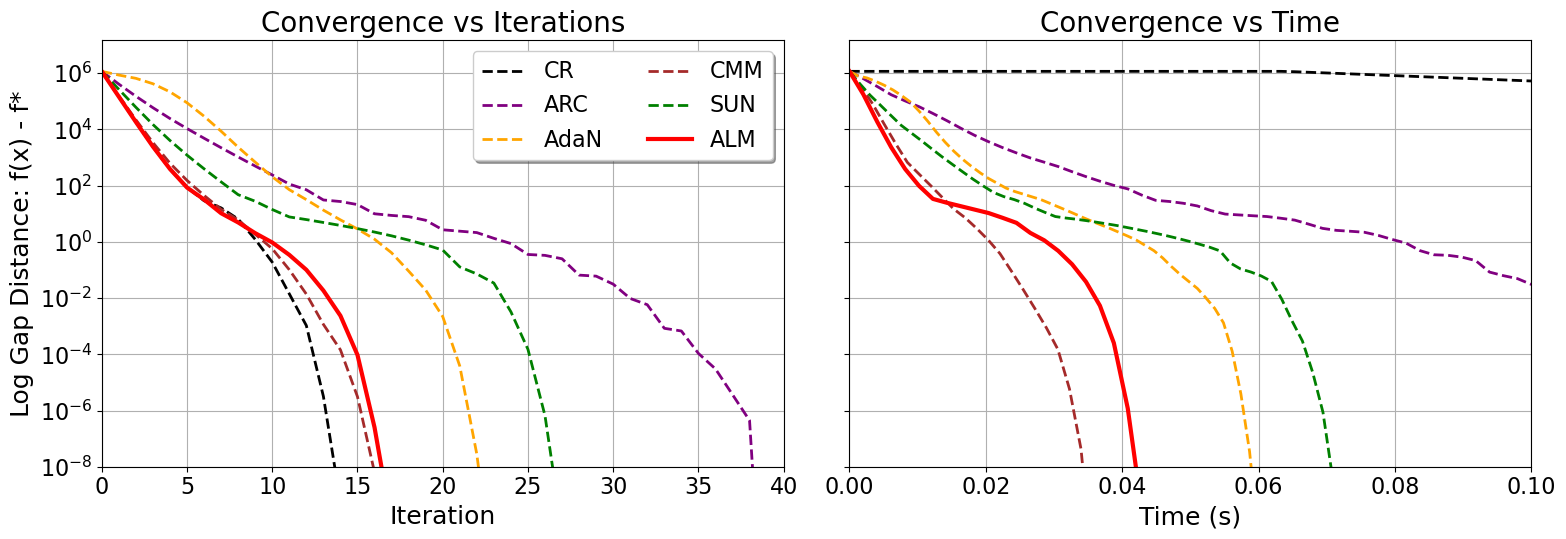

In [9]:
if __name__ == "__main__":
    # 测试所有问题
    problems_to_test = ["polytope"]
    
    # 定义要测试的p_param值
    p_params_to_test = [3]
    
    for problem in problems_to_test:
        for p_param in p_params_to_test:
            print(f"\n{'='*60}")
            print(f"Testing {problem} with p={p_param}")
            print(f"{'='*60}")
            
            tester = OptimizerTester(
                optimizers=[
                    CR(),
                    ARC(),
                    AdaN(),
                    CubicMM(),
                    SuperUniversalNewton(),
                    Algorithm1(alpha=1/2,beta=1/3),
                ],
                dim=200,          
                n_runs=1,         
                max_iter=40,
                problem_type=problem, 
                p_param=p_param,   # 当前测试的p值
            )
            tester.run_test()
            tester.plot_results(time_range=[0,0.1])
            # 可选：保存结果或图表
            #plt.savefig(f"{problem}_p{p_param}_results.png", dpi=300, bbox_inches='tight')
            plt.close()
    



Testing worst_instances with q=3.5

Testing on Worst Instances Function (dim=200)

Testing CR...
  Run 1/1

Testing ARC...
  Run 1/1

Testing AdaN...
  Run 1/1

Testing CMM...
  Run 1/1

Testing SUN...
  Run 1/1

Testing ALM...
  Run 1/1


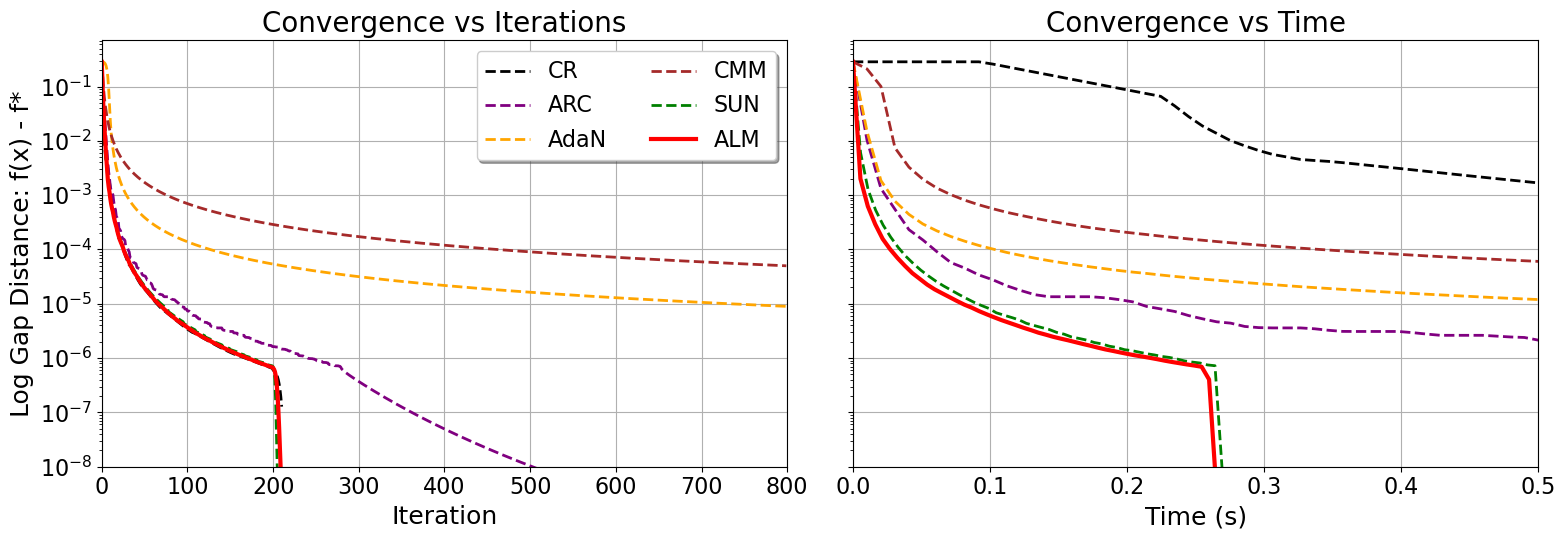

In [10]:
if __name__ == "__main__":
    for q_param in [3.5]:
        print(f"\n{'='*60}")
        print(f"Testing worst_instances with q={q_param}")
        print(f"{'='*60}")
        
        tester = OptimizerTester(            
            optimizers=[
                CR(),
                ARC(),
                AdaN(),
                CubicMM(L_fixed=48),
                SuperUniversalNewton(),
                Algorithm1(alpha=1/2,beta=1/3),
            ],
            dim=200,
            n_runs=1,
            max_iter=800,
            tol=1e-8,
            problem_type="worst_instances", 
            q_param=q_param,
        )
        
        tester.run_test()
        tester.plot_results(time_range=[0, 0.5])


Testing on Log-Sum-Exp Function (dim=100)

Testing CR...
  Run 1/1

Testing ARC...
  Run 1/1

Testing AdaN...
  Run 1/1

Testing CMM...
  Run 1/1

Testing SUN...
  Run 1/1

Testing ALM...
  Run 1/1


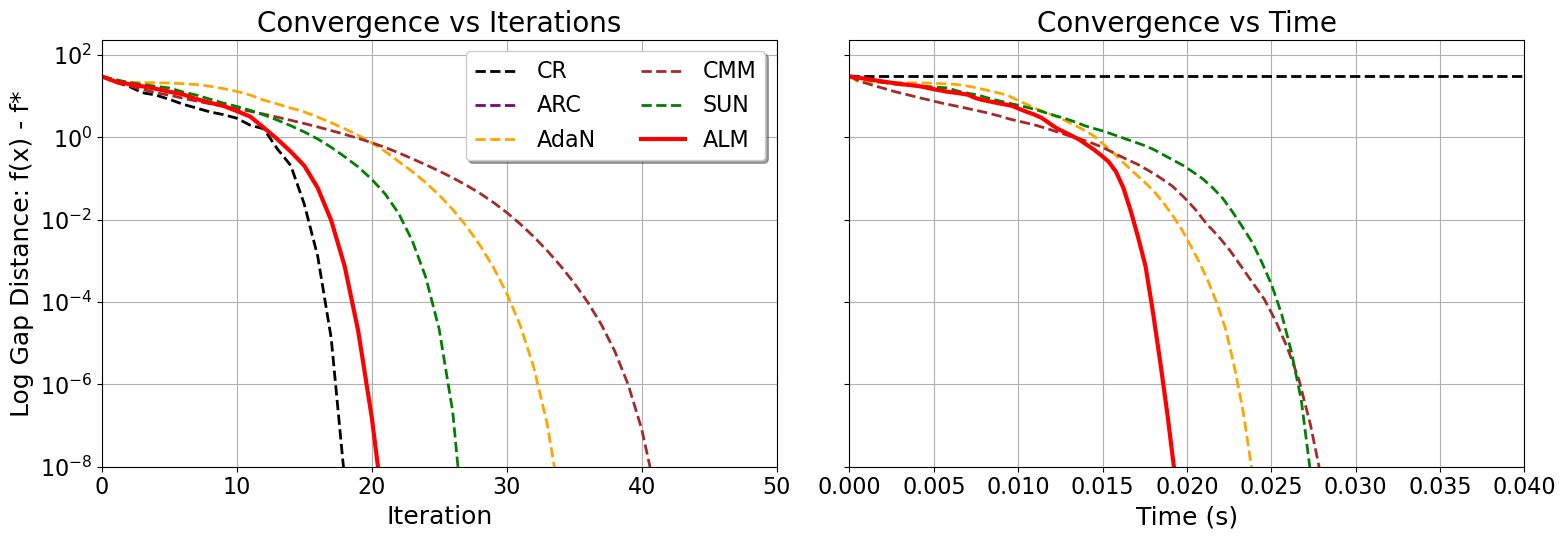

In [20]:
if __name__ == "__main__":
    # 测试LogSumExp问题
    tester = OptimizerTester(
        optimizers=[
                CR(),
                ARC(),
                AdaN(),
                CubicMM(L_fixed=10),
                SuperUniversalNewton(),
                Algorithm1(alpha=1/2,beta=1/3),
            ],
        problem_type="logsumexp",
        dim=100,
        lse_n=300,
        lse_rho=0.5,
        max_iter=50,
    )
    
    tester.run_test()
    tester.plot_results(time_range=[0, 0.04])


Testing on Rosenbrock Function (dim=200)

Testing CR...
  Run 1/1

Testing ARC...
  Run 1/1

Testing AdaN...
  Run 1/1

Testing CMM...
  Run 1/1

Testing SUN...
  Run 1/1

Testing ALM...
  Run 1/1


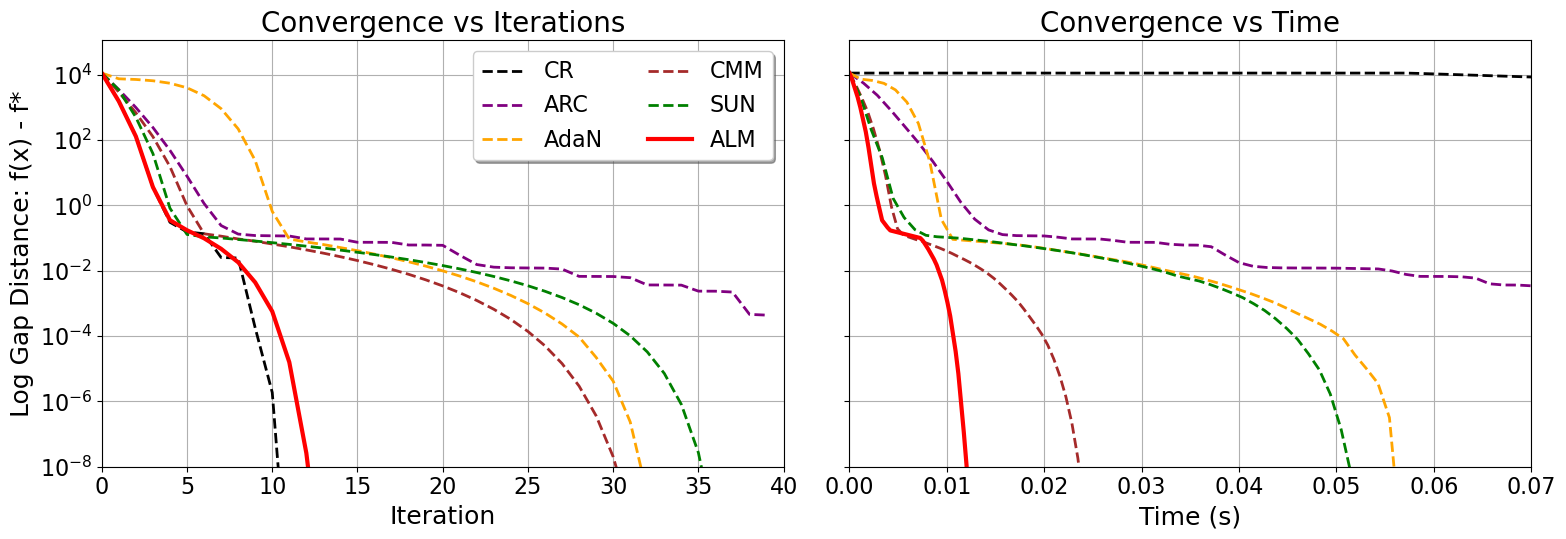

In [6]:
if __name__ == "__main__":
    tester = OptimizerTester(
        optimizers=[
                CR(),
                ARC(),
                AdaN(),
                CubicMM(L_fixed=100),
                SuperUniversalNewton(),
                Algorithm1(alpha=1/2,beta=1/3),
            ],
        problem_type="rosenbrock",
        dim=200,
        max_iter=40,
    )
    
    tester.run_test()
    tester.plot_results(time_range=[0, 0.07])

In [19]:
class MultivariateTTest:
    """多元t分布MLE专门测试类"""
    
    def __init__(self, optimizers=None, dim=10, n_samples=1000, df_true=5.0, max_iter=100):
        self.optimizers = optimizers or [
            CR(),
            ARC(),
            AdaN(),
            Algorithm1(alpha=1/2,beta=1/3),
            Algorithm1Acc(alpha=1/2,beta=1/3),
            SuperUniversalNewton(),
            CubicMM(L_fixed=1e4),
            ECME(),
        ]
        self.dim = dim
        self.n_samples = n_samples
        self.df_true = df_true
        self.max_iter = max_iter
        self.results = {}
        
        # 创建多元t分布MLE问题实例
        self.model = MultivariateTMLE(
            n_samples=n_samples, 
            dim=dim, 
            df_true=df_true
        )
        
        # 存储最优损失值（用于计算间隙）
        self.optimal_loss = None
    
    def run_test(self):
        """运行多元t分布MLE测试"""
        print(f"\nTesting Multivariate t-distribution MLE")
        print(f"Dimension: {self.dim}, Samples: {self.n_samples}, True df: {self.df_true}")
        print(f"Stopping criterion: gradient norm < 1e-8")
        
        initial_theta = self.model.get_initial_guess()
        param_count = self.model.get_parameter_count()
        print(f"Total parameters to estimate: {param_count}")
        
        for optimizer in self.optimizers:
            print(f"\nTesting {optimizer.name}...")
            
            # 运行优化
            theta_opt = optimizer.optimize(
                self.model, 
                param_count,
                initial_theta=initial_theta,
                max_iter=self.max_iter,
                tol=1e-7  # 修改停止准则为梯度范数 
            )
            
            # 评估估计质量
            estimation_quality = self.model.evaluate_estimation(theta_opt)
            
            self.results[optimizer.name] = {
                'history': optimizer.history.copy(),
                'estimation_quality': estimation_quality,
                'final_theta': theta_opt
            }
            
            print(f"  Final loss: {optimizer.history['loss'][-1]:.6f}")
            print(f"  Final gradient norm: {optimizer.history['grad_norm'][-1]:.6e}")
            print(f"  Mu error: {estimation_quality['mu_error']:.6f}")
            print(f"  Sigma error: {estimation_quality['Sigma_error']:.6f}")
            print(f"  Nu error: {estimation_quality['nu_error']:.6f}")
        
        # 计算最优损失值（所有算法中的最小值）
        all_losses = []
        for result in self.results.values():
            history = result['history']
            if history['loss']:
                all_losses.extend(history['loss'])
        self.optimal_loss = min(all_losses) if all_losses else 0
    
    def plot_results(self, iter_range=None, time_range=None, figsize=(16, 6), wspace=0.05):
        """
        绘制多元t分布MLE的优化结果 - 显示对数间隙距离
        
        参数:
        iter_range: tuple (start, end) 迭代次数显示范围，None表示自动，例如 (0, 50)
        time_range: tuple (start, end) 时间显示范围，None表示自动，例如 (0, 10)
        figsize: tuple (width, height) 图像大小，默认(16, 6)
        wspace: float 子图之间的间距，默认0.05（很小的间距）
        """
        problem_name = f"Multivariate t-distribution MLE"
        title = f"{problem_name} (dim={self.dim}, n_samples={self.n_samples}, df_true={self.df_true})"
        
        # 设置字体大小
        plt.rcParams.update({
            'font.size': 14,
            'axes.labelsize': 14,
            'xtick.labelsize': 12,
            'ytick.labelsize': 12,
            'legend.fontsize': 11,
        })
        
        # 定义线型样式
        styles = {
            'ARC': {'color': 'purple', 'linestyle': '--', 'linewidth': 3},
            'AdaN': {'color': 'orange', 'linestyle': '--', 'linewidth': 3},
            'ALM': {'color': 'red', 'linestyle': '-', 'linewidth': 3},
            'SUN': {'color': 'green', 'linestyle': '--', 'linewidth': 3},
            'CR': {'color': 'black', 'linestyle': '--', 'linewidth': 3},
            'CMM': {'color': 'brown', 'linestyle': '--', 'linewidth': 3},
            'ECME': {'color': 'black', 'linestyle': ':', 'linewidth': 3},
        }
        
        # 创建图像，设置子图间距
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        plt.subplots_adjust(wspace=wspace)  # 设置子图间距
        
        # 分别存储两个子图的收敛数据
        convergence_data_iter = {}  # 迭代次数的收敛数据
        convergence_data_time = {}  # 时间的收敛数据
        
        # 收集所有算法的对数间隙数据，用于确定Y轴范围
        all_gaps_iter = []
        all_gaps_time = []
        
        # 1. 对数间隙距离 vs 迭代
        for name, result in self.results.items():
            history = result['history']
            if history['loss'] and history['time']:
                losses = history['loss']
                times = history['time']
                
                # 计算间隙并取对数
                gaps = []
                for loss in losses:
                    gap = max(loss - self.optimal_loss, 1e-16)  # 避免负值和零值
                    gaps.append(np.log10(gap))
                
                # 确保长度一致
                min_len = min(len(gaps), len(times))
                if min_len > 0:
                    gaps = gaps[:min_len]
                    times = times[:min_len]
                    
                    # 存储所有间隙数据
                    all_gaps_iter.extend(gaps)
                    
                    # 绘制对数间隙曲线
                    iterations = range(len(gaps))
                    ax1.plot(iterations, gaps, label=name, **styles.get(name, {}))
                    
                    # 计算收敛数据（达到目标间隙）
                    target_gap = np.log10(1e-12)  # 目标间隙为1e-6，对应log10 = -6
                    convergence_iter = None
                    convergence_time = None
                    final_gap = gaps[-1] if gaps else 0
                    
                    for i, gap in enumerate(gaps):
                        if gap <= target_gap:
                            convergence_iter = i
                            if i < len(times):
                                convergence_time = times[i]
                            break
                    
                    # 如果没有达到收敛标准，使用最后一次迭代的数据
                    if convergence_iter is None:
                        convergence_iter = len(gaps) - 1
                        convergence_time = times[-1] if times else 0
                    
                    convergence_data_iter[name] = {
                        'iteration': convergence_iter,
                        'time': convergence_time,
                        'final_gap': final_gap,
                        'converged': convergence_iter < len(gaps) - 1 or final_gap <= target_gap
                    }
        
        ax1.set_xlabel('Iteration', fontsize=14)
        ax1.set_ylabel(r'$f(x) - f^*$ (log scale)', fontsize=14)
        ax1.grid(True, alpha=0.6)
        
        # 设置Y轴刻度标签为10^x形式
        def format_y_tick(value, pos):
            """将数值格式化为10^x形式"""
            return f'$10^{{{int(value)}}}$'
        
        # 设置Y轴范围：从起始点高度开始
        if all_gaps_iter:
            # 找到起始点的最大值（即第一个点）
            start_gaps = []
            for name, result in self.results.items():
                history = result['history']
                if history['loss']:
                    losses = history['loss']
                    if losses:
                        gap = max(losses[0] - self.optimal_loss, 1e-16)
                        start_gaps.append(np.log10(gap))
            
            if start_gaps:
                y_max = max(start_gaps) + 0.5  # 在最高起始点基础上加一点余量
                y_min = -12  # 下限
                ax1.set_ylim(bottom=y_min, top=y_max)
                
                # 设置Y轴刻度
                y_ticks = np.arange(int(np.floor(y_min)), int(np.ceil(y_max)) + 1, 2)
                ax1.set_yticks(y_ticks)
                ax1.set_yticklabels([format_y_tick(tick, None) for tick in y_ticks])
        
        # 设置迭代次数显示范围
        if iter_range is not None:
            ax1.set_xlim(iter_range[0], iter_range[1])
        
        ax1.set_title('Log Gap vs Iterations', fontsize=15)
        # 设置图例为两列，放在左下角避免遮挡
        ax1.legend(ncol=2, loc='lower left', framealpha=0.9, fontsize=11)
        
        # 2. 对数间隙距离 vs 时间
        for name, result in self.results.items():
            history = result['history']
            if history['loss'] and history['time']:
                losses = history['loss']
                times = history['time']
                
                # 计算间隙并取对数
                gaps = []
                for loss in losses:
                    gap = max(loss - self.optimal_loss, 1e-16)
                    gaps.append(np.log10(gap))
                
                # 确保时间和损失长度一致
                min_len = min(len(times), len(gaps))
                if min_len > 1:  # 至少需要2个点才能插值
                    times = times[:min_len]
                    gaps = gaps[:min_len]
                    
                    # 存储所有间隙数据
                    all_gaps_time.extend(gaps)
                    
                    # 确保时间是递增的
                    if times[-1] > times[0]:
                        # 创建时间采样点
                        if time_range is None:
                            time_end = times[-1]
                        else:
                            time_end = min(times[-1], time_range[1])
                        
                        # 动态采样点数
                        num_samples = max(50, min(200, int(time_end * 10)))
                        time_samples = np.linspace(0, time_end, num_samples)
                        
                        # 插值
                        interp_gaps = np.interp(time_samples, times, gaps)
                        
                        # 绘制曲线
                        ax2.plot(time_samples, interp_gaps, 
                                **styles.get(name, {}))
                        
                        # 计算收敛数据
                        target_gap = np.log10(1e-12)
                        final_gap = interp_gaps[-1]
                        convergence_time = None
                        
                        for i, gap in enumerate(interp_gaps):
                            if gap <= target_gap and i < len(time_samples):
                                convergence_time = time_samples[i]
                                break
                        
                        convergence_data_time[name] = {
                            'time': convergence_time if convergence_time is not None else time_samples[-1],
                            'final_gap': final_gap,
                            'converged': convergence_time is not None
                        }
        
        ax2.set_xlabel('Time (seconds)', fontsize=14)
        # 去掉第二张图的y轴标签，但保留刻度线
        ax2.set_ylabel('')  # 清空y轴标签
        ax2.grid(True, ls='-', alpha=1)
        
        # 设置Y轴范围并保留刻度线，但隐藏刻度标签
        if all_gaps_time:
            # 找到起始点的最大值
            start_gaps_time = []
            for name, result in self.results.items():
                history = result['history']
                if history['loss'] and history['time']:
                    losses = history['loss']
                    if losses:
                        gap = max(losses[0] - self.optimal_loss, 1e-16)
                        start_gaps_time.append(np.log10(gap))
            
            if start_gaps_time:
                y_max = max(start_gaps_time) + 0.5
                y_min = -12
                ax2.set_ylim(bottom=y_min, top=y_max)
                
                # 设置Y轴刻度位置
                y_ticks = np.arange(int(np.floor(y_min)), int(np.ceil(y_max)) + 1, 2)
                ax2.set_yticks(y_ticks)
                # 隐藏刻度标签，但保留刻度线
                ax2.set_yticklabels([])
                # 确保刻度线仍然显示
                ax2.tick_params(left=True, labelleft=False)
        
        # 设置时间显示范围
        if time_range is not None:
            ax2.set_xlim(time_range[0], time_range[1])
        
        ax2.set_title('Log Gap vs Time', fontsize=15)
        # 右子图不显示图例
        
        plt.tight_layout()
        plt.show()
    


Testing Multivariate t-distribution MLE
Dimension: 10, Samples: 100, True df: 0.5
Stopping criterion: gradient norm < 1e-8
Total parameters to estimate: 66

Testing CR...
CR: All inner iterations failed at outer iter 44, sigma increased to 1.31e+05
CR: All inner iterations failed at outer iter 97, sigma increased to 6.25e-02
CR: All inner iterations failed at outer iter 98, sigma increased to 1.31e+05
CR: All inner iterations failed at outer iter 146, sigma increased to 2.50e-01
CR: All inner iterations failed at outer iter 147, sigma increased to 5.24e+05
CR: All inner iterations failed at outer iter 190, sigma increased to 4.00e+00
CR: All inner iterations failed at outer iter 220, sigma increased to 2.56e+02
  Final loss: 4021.428825
  Final gradient norm: 3.050246e-13
  Mu error: 0.110828
  Sigma error: 0.564138
  Nu error: 0.055370

Testing ARC...
  Final loss: 4518.992847
  Final gradient norm: 3.275086e-02
  Mu error: 1.079035
  Sigma error: 158675.741905
  Nu error: 0.000472



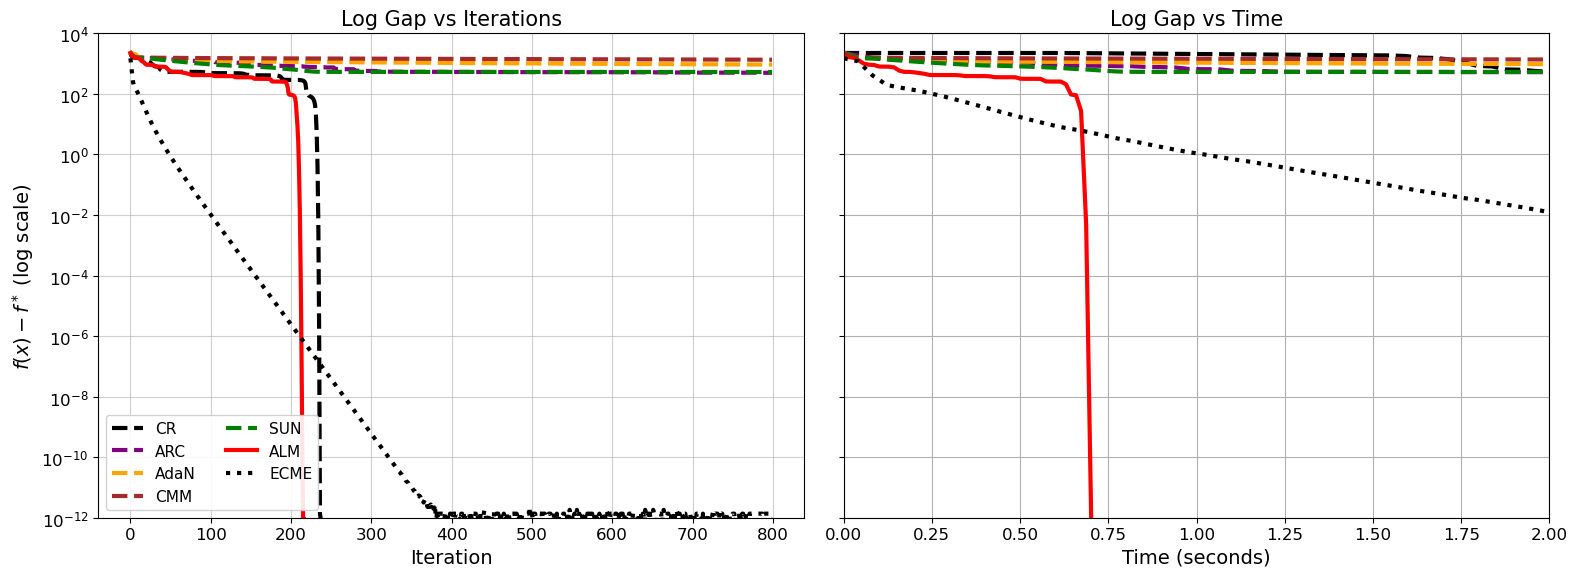

In [20]:
# 创建测试实例
tester = MultivariateTTest(
    optimizers=[
                CR(),
                ARC(),
                AdaN(),
                CubicMM(L_fixed=1000),
                SuperUniversalNewton(),
                Algorithm1(alpha=1/2,beta=1/3),
                ECME(),
                
     ],
    dim=10,
    n_samples=100,
    df_true=0.5,
    max_iter=800
)

# 运行测试
tester.run_test()


# 或指定时间范围
tester.plot_results(time_range=[0,2])


Algorithm1 Parameter Grid Test - Heatmap Visualization
Algorithm1 Parameter Grid Analysis - LogSumExp Problem
Grid: 20×20 points in α+β<1 region
Dimension=50, LSE_n=150, LSE_rho=0.005

[1/3] Creating parameter grid...
Creating parameter grid in α+β<1 region...
Parameter grid: 240/400 valid points (60.0%)

[2/3] Running parameter grid test...

Starting parameter grid test: 240 configurations, 10 runs each
Total runs: 2400


Testing configurations: 100%|██████████| 240/240 [16:23<00:00,  4.10s/config, alpha=0.700, beta=0.287, iter=350.0]



Test completed in 983.1s
Average time per config: 4.10s
Convergence rate: 238/240 (99.2%)

[3/3] Generating heatmaps...

Generating heatmaps...
Best configuration: α=0.226, β=0.524, iter=211.0


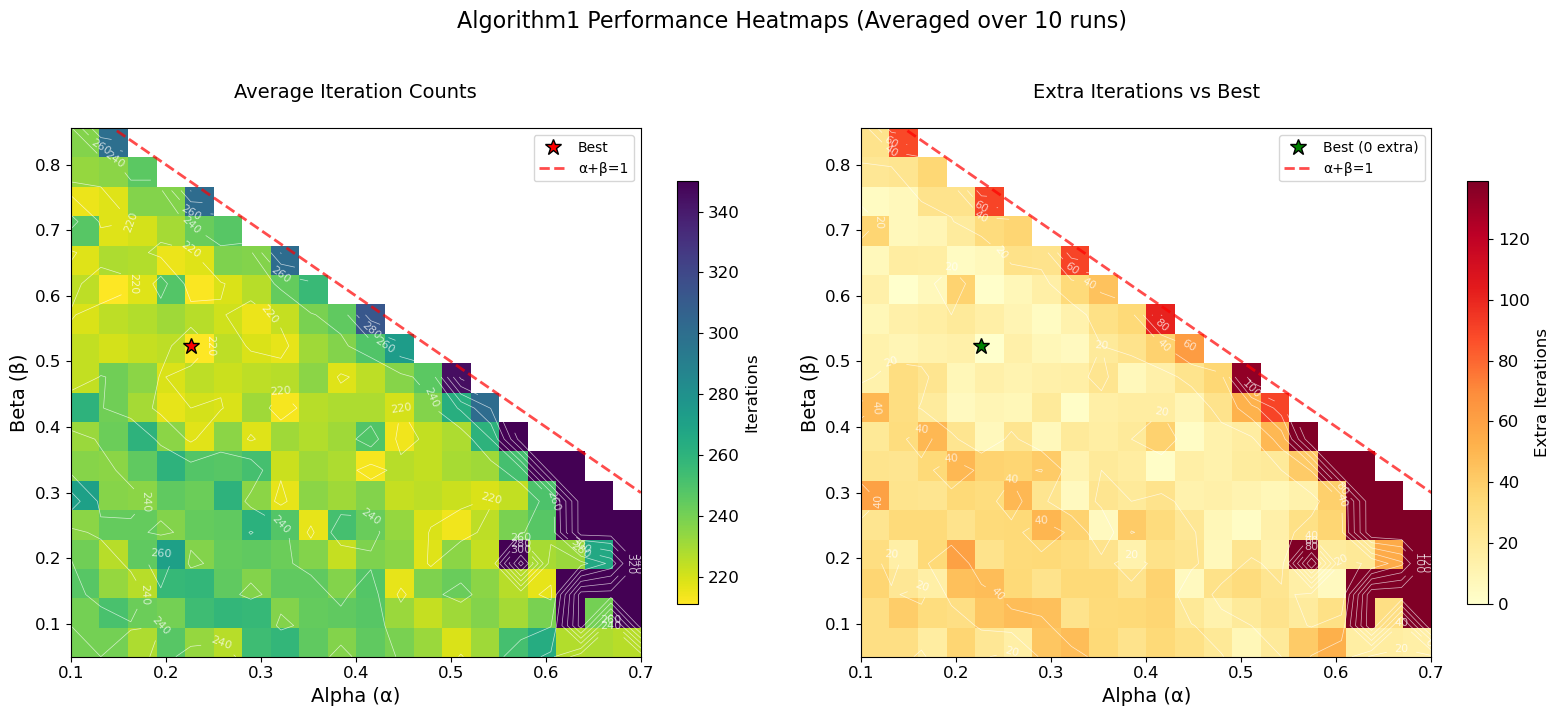


Analysis completed successfully!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Any
import time
from tqdm import tqdm
from matplotlib import cm
import sys
from io import StringIO

class Alg1ParameterGridTester:
    """专门测试Algorithm1在不同参数下的表现（多次运行取均值）"""
    
    def __init__(self, dim=200, lse_n=300, lse_rho=0.05, max_iter=200, n_runs=3):
        """
        Args:
            dim: 问题维度
            lse_n: LogSumExp问题中的项数
            lse_rho: LogSumExp的平滑参数
            max_iter: 最大迭代次数
            n_runs: 每个配置的运行次数
        """
        self.dim = dim
        self.lse_n = lse_n
        self.lse_rho = lse_rho
        self.max_iter = max_iter
        self.n_runs = n_runs
        self.results = {}
        
        # 设置字体
        plt.rcParams.update({
            'font.size': 12,
            'axes.labelsize': 14,
            'xtick.labelsize': 12,
            'ytick.labelsize': 12,
            'legend.fontsize': 10,
        })
    
    def create_parameter_grid(self, alpha_density=10, beta_density=8, safety_margin=0.01):
        """
        在alpha+beta<1的区域内创建参数网格
        
        Args:
            alpha_density: alpha维度采样密度
            beta_density: beta维度采样密度
            safety_margin: 安全边界
        """
        print(f"Creating parameter grid in α+β<1 region...")
        
        param_combinations = []
        
        # 定义参数范围
        alpha_min, alpha_max = 0.1, 0.7
        beta_min, beta_max = 0.05, 0.95
        
        # 创建网格
        alphas = np.linspace(alpha_min, alpha_max, alpha_density)
        betas = np.linspace(beta_min, beta_max, beta_density)
        
        total_possible = len(alphas) * len(betas)
        valid_count = 0
        
        for alpha in alphas:
            for beta in betas:
                if alpha + beta <= 1 - safety_margin:
                    sum_ab = alpha + beta
                    distance_to_one = 1.0 - sum_ab
                    
                    param_combinations.append({
                        'alpha': float(alpha),
                        'beta': float(beta),
                        'alpha_beta_sum': float(sum_ab),
                        'distance_to_one': float(distance_to_one),
                        'name': f'Alg1_α={alpha:.3f}_β={beta:.3f}'
                    })
                    valid_count += 1
        
        print(f"Parameter grid: {valid_count}/{total_possible} valid points ({valid_count/total_possible*100:.1f}%)")
        
        return param_combinations
    
    def run_parameter_test(self, param_grid):
        """运行参数网格测试 - 每个配置运行多次取均值"""
        print(f"\nStarting parameter grid test: {len(param_grid)} configurations, {self.n_runs} runs each")
        print(f"Total runs: {len(param_grid) * self.n_runs}")
        
        self.results = {}
        total_configs = len(param_grid)
        
        start_time_total = time.time()
        
        # 使用进度条
        with tqdm(total=total_configs, desc="Testing configurations", unit="config") as pbar:
            for params in param_grid:
                # 存储多次运行的结果
                all_iterations = []
                all_final_losses = []
                all_final_grad_norms = []
                all_histories = []
                all_converged = []
                
                # 运行多次
                for run_idx in range(self.n_runs):
                    # 临时重定向标准输出以抑制print
                    old_stdout = sys.stdout
                    sys.stdout = StringIO()
                    
                    try:
                        # 创建Algorithm1优化器（每次都重新创建以确保状态重置）
                        optimizer = Algorithm1(alpha=params['alpha'], beta=params['beta'])
                        optimizer.name = params['name']
                        
                        # 创建测试器（每次都重新创建以确保独立性）
                        tester = OptimizerTester(
                            optimizers=[optimizer],
                            problem_type="logsumexp",
                            dim=self.dim,
                            lse_n=self.lse_n,
                            lse_rho=self.lse_rho,
                            max_iter=self.max_iter,
                            n_runs=1
                        )
                        
                        # 运行测试
                        tester.run_test()
                    finally:
                        # 恢复标准输出
                        sys.stdout = old_stdout
                    
                    # 提取结果
                    optimizer_name = params['name']
                    
                    if optimizer_name in tester.results:
                        runs_data = tester.results[optimizer_name]
                        
                        if runs_data and len(runs_data) > 0:
                            history = runs_data[0]
                            
                            # 获取迭代次数
                            if 'loss' in history and history['loss']:
                                iterations = len(history['loss'])
                            else:
                                iterations = self.max_iter
                            
                            # 获取最终损失
                            if 'loss' in history and history['loss']:
                                final_loss = history['loss'][-1]
                            else:
                                final_loss = float('inf')
                            
                            # 获取最终梯度范数
                            if 'grad_norm' in history and history['grad_norm']:
                                final_grad_norm = history['grad_norm'][-1]
                            else:
                                final_grad_norm = float('inf')
                            
                            # 检查是否收敛
                            converged = final_grad_norm < 1e-4 if final_grad_norm != float('inf') else False
                            
                            # 保存本次运行的结果
                            all_iterations.append(iterations)
                            all_final_losses.append(final_loss)
                            all_final_grad_norms.append(final_grad_norm)
                            all_histories.append(history)
                            all_converged.append(converged)
                        else:
                            # 如果运行数据为空
                            all_iterations.append(self.max_iter)
                            all_final_losses.append(float('inf'))
                            all_final_grad_norms.append(float('inf'))
                            all_histories.append({})
                            all_converged.append(False)
                    else:
                        # 如果优化器名称不在结果中
                        all_iterations.append(self.max_iter)
                        all_final_losses.append(float('inf'))
                        all_final_grad_norms.append(float('inf'))
                        all_histories.append({})
                        all_converged.append(False)
                
                # 计算多次运行的平均值
                valid_iterations = [it for it in all_iterations if it != self.max_iter]
                valid_losses = [loss for loss in all_final_losses if loss != float('inf')]
                valid_grad_norms = [norm for norm in all_final_grad_norms if norm != float('inf')]
                
                avg_iterations = np.mean(valid_iterations) if valid_iterations else self.max_iter
                avg_final_loss = np.mean(valid_losses) if valid_losses else float('inf')
                avg_final_grad_norm = np.mean(valid_grad_norms) if valid_grad_norms else float('inf')
                converged_rate = np.mean(all_converged)
                
                # 保存平均结果
                self.results[params['name']] = {
                    'alpha': params['alpha'],
                    'beta': params['beta'],
                    'alpha_beta_sum': params['alpha_beta_sum'],
                    'distance_to_one': params['distance_to_one'],
                    'avg_iterations': avg_iterations,
                    'avg_final_loss': avg_final_loss,
                    'avg_final_grad_norm': avg_final_grad_norm,
                    'converged_rate': converged_rate,
                    'all_iterations': all_iterations,
                    'all_final_losses': all_final_losses,
                    'all_histories': all_histories,
                    'all_converged': all_converged,
                    'iterations_std': np.std(valid_iterations) if len(valid_iterations) > 1 else 0,
                    'converged': converged_rate > 0.5
                }
                
                # 更新进度条
                pbar.set_postfix({
                    'alpha': f'{params["alpha"]:.3f}',
                    'beta': f'{params["beta"]:.3f}',
                    'iter': f'{avg_iterations:.1f}'
                })
                pbar.update(1)
        
        # 总体统计
        total_time = time.time() - start_time_total
        print(f"\nTest completed in {total_time:.1f}s")
        print(f"Average time per config: {total_time/total_configs:.2f}s")
        
        # 统计收敛情况
        converged_count = sum(1 for result in self.results.values() if result['converged'])
        total_count = len(self.results)
        print(f"Convergence rate: {converged_count}/{total_count} ({converged_count/total_count*100:.1f}%)")
        
        return self.results
    
    def plot_heatmaps(self):
        """绘制两个热力图（迭代次数和额外迭代次数）"""
        if not self.results:
            print("No results to plot.")
            return
        
        print("\nGenerating heatmaps...")
        
        # 提取数据
        alphas = []
        betas = []
        avg_iterations = []
        converged_flags = []
        
        for name, result in self.results.items():
            alphas.append(result['alpha'])
            betas.append(result['beta'])
            avg_iterations.append(result['avg_iterations'])
            converged_flags.append(result['converged'])
        
        if not alphas:
            print("No valid data.")
            return
        
        # 只考虑收敛的配置
        converged_indices = [i for i, converged in enumerate(converged_flags) if converged]
        
        if not converged_indices:
            print("No configurations converged!")
            return
        
        # 只考虑收敛的配置用于热力图
        converged_alphas = [alphas[i] for i in converged_indices]
        converged_betas = [betas[i] for i in converged_indices]
        converged_avg_iters = [avg_iterations[i] for i in converged_indices]
        
        # 创建网格用于插值
        alpha_vals = sorted(set(converged_alphas))
        beta_vals = sorted(set(converged_betas))
        
        # 创建网格矩阵
        grid_iters = np.full((len(beta_vals), len(alpha_vals)), np.nan)
        
        # 填充网格值
        for alpha, beta, avg_iter in zip(converged_alphas, converged_betas, converged_avg_iters):
            try:
                alpha_idx = alpha_vals.index(alpha)
                beta_idx = beta_vals.index(beta)
                grid_iters[beta_idx, alpha_idx] = avg_iter
            except ValueError:
                continue
        
        # 找到全局最优配置（迭代次数最少）
        min_idx = np.unravel_index(np.nanargmin(grid_iters), grid_iters.shape)
        best_alpha = alpha_vals[min_idx[1]]
        best_beta = beta_vals[min_idx[0]]
        best_iter = grid_iters[min_idx[0], min_idx[1]]
        
        print(f"Best configuration: α={best_alpha:.3f}, β={best_beta:.3f}, iter={best_iter:.1f}")
        
        # 创建图形 - 只保留前两张图
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        fig.suptitle(f'Algorithm1 Performance Heatmaps (Averaged over {self.n_runs} runs)', 
                    fontsize=16, y=1.02)
        
        X, Y = np.meshgrid(alpha_vals, beta_vals)
        
        # 1. 原始迭代次数热力图
        ax1 = axes[0]
        if np.any(~np.isnan(grid_iters)):
            im1 = ax1.imshow(grid_iters, aspect='auto', origin='lower',
                           extent=[min(alpha_vals), max(alpha_vals), 
                                   min(beta_vals), max(beta_vals)],
                           cmap='viridis_r')  # 反转viridis，让蓝色表示少迭代
            ax1.set_xlabel('Alpha (α)', fontsize=14)
            ax1.set_ylabel('Beta (β)', fontsize=14)
            ax1.set_title('Average Iteration Counts\n', fontsize=14)
            
            # 添加颜色条
            cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.8)
            cbar1.set_label('Iterations', fontsize=12)
            
            # 添加等高线
            CS = ax1.contour(X, Y, grid_iters, colors='white', alpha=0.7, linewidths=0.5)
            ax1.clabel(CS, CS.levels, inline=True, fontsize=8, fmt='%.0f')
            
            # 标记最佳配置（红色星星）
            ax1.plot(best_alpha, best_beta, 'r*', markersize=12, 
                    markeredgecolor='black', label=f'Best')
            
            # 添加α+β=1的线
            x_line = np.linspace(min(alpha_vals), max(alpha_vals), 100)
            y_line = 1.0 - x_line
            valid_idx = (y_line >= min(beta_vals)) & (y_line <= max(beta_vals))
            if np.any(valid_idx):
                ax1.plot(x_line[valid_idx], y_line[valid_idx], 'r--', 
                        linewidth=2, alpha=0.7, label='α+β=1')
            
            ax1.legend(loc='upper right')
        else:
            ax1.text(0.5, 0.5, 'No data available', ha='center', va='center')
            ax1.set_xlabel('Alpha (α)')
            ax1.set_ylabel('Beta (β)')
            ax1.set_title('Average Iteration Counts')
        
        # 2. 相对于最快配置的额外迭代次数热力图
        ax2 = axes[1]
        extra_iter_grid = grid_iters - best_iter
        extra_iter_grid[extra_iter_grid < 0] = 0  # 确保非负
        
        if np.any(~np.isnan(extra_iter_grid)):
            im2 = ax2.imshow(extra_iter_grid, aspect='auto', origin='lower',
                           extent=[min(alpha_vals), max(alpha_vals), 
                                   min(beta_vals), max(beta_vals)],
                           cmap='YlOrRd')  # 黄色到红色，表示额外迭代次数
            ax2.set_xlabel('Alpha (α)', fontsize=14)
            ax2.set_ylabel('Beta (β)', fontsize=14)
            ax2.set_title('Extra Iterations vs Best\n', fontsize=14)
            
            cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.8)
            cbar2.set_label('Extra Iterations', fontsize=12)
            
            # 添加等高线
            CS2 = ax2.contour(X, Y, extra_iter_grid, colors='white', alpha=0.7, linewidths=0.5)
            ax2.clabel(CS2, CS2.levels, inline=True, fontsize=8, fmt='%.0f')
            
            # 标记最佳配置（与第一张图相同位置的绿色星星）
            ax2.plot(best_alpha, best_beta, 'g*', markersize=12, 
                    markeredgecolor='black', label=f'Best (0 extra)')
            
            # 添加α+β=1的线
            if np.any(valid_idx):
                ax2.plot(x_line[valid_idx], y_line[valid_idx], 'r--', 
                        linewidth=2, alpha=0.7, label='α+β=1')
            
            ax2.legend(loc='upper right')
        else:
            ax2.text(0.5, 0.5, 'No data available', ha='center', va='center')
            ax2.set_xlabel('Alpha (α)')
            ax2.set_ylabel('Beta (β)')
            ax2.set_title('Extra Iterations vs Best')
        
        plt.tight_layout()
        plt.show()
    
    def run_comprehensive_analysis(self, alpha_density=10, beta_density=8):
        """运行完整的分析流程"""
        print("="*80)
        print(f"Algorithm1 Parameter Grid Analysis - LogSumExp Problem")
        print(f"Grid: {alpha_density}×{beta_density} points in α+β<1 region")
        print(f"Dimension={self.dim}, LSE_n={self.lse_n}, LSE_rho={self.lse_rho}")
        print("="*80)
        
        # 1. 创建参数网格
        print("\n[1/3] Creating parameter grid...")
        param_grid = self.create_parameter_grid(
            alpha_density=alpha_density,
            beta_density=beta_density,
            safety_margin=0.001
        )
        
        # 2. 运行参数测试
        print(f"\n[2/3] Running parameter grid test...")
        results = self.run_parameter_test(param_grid)
        
        # 3. 绘制热力图
        print("\n[3/3] Generating heatmaps...")
        self.plot_heatmaps()
        
        print("\n" + "="*80)
        print("Analysis completed successfully!")
        print("="*80)


# 使用示例
if __name__ == "__main__":
    print("="*80)
    print("Algorithm1 Parameter Grid Test - Heatmap Visualization")
    print("="*80)
    
    # 创建测试器
    tester = Alg1ParameterGridTester(
        dim=50,           # 降低维度以加快测试速度
        lse_n=150,        # LogSumExp项数
        lse_rho=0.005,    # 平滑参数
        max_iter=350,     # 最大迭代次数
        n_runs=10          # 每个配置运行1次
    )
    
    # 运行完整分析
    tester.run_comprehensive_analysis(
        alpha_density=20,   # alpha采样密度
        beta_density=20     # beta采样密度
    )

Multivariate t-distribution MLE - Uniform Grid Analysis
Grid: 20×20 points in α+β<1 region
Dimension=5, Samples=100, df_true=0.5

[1/2] Running tests...

Running Multivariate t-distribution MLE tests
  Uniform grid: α×β = 20×20
  Dimension: 5, Samples: 100
  True df: 0.5, Max iterations: 200
  Runs per config: 10
Creating uniform grid in α+β<1 region...
Uniform grid: 263/400 valid points (65.8%)

Total: 263 parameter combinations × 10 runs = 2630 tests


Testing configurations: 100%|██████████| 263/263 [46:36<00:00, 10.63s/config, alpha=0.600, beta=0.382, iter=200.0]



Test completed in 2796.8s
Average time per configuration: 10.63s

[2/2] Generating results summary and visualizations...

RESULTS SUMMARY
Total configurations: 263
Alpha range: [0.100, 0.600]
Beta range: [0.050, 0.855]
Alpha+beta range: [0.1500, 0.9974]

Iteration statistics:
  Min: 96.0
  Max: 200.0
  Mean: 129.4
  Std: 22.9

Performance by α+β region:
  α+β ∈ [0.5, 0.7): 77 points, avg iter=132.0
  α+β ∈ [0.7, 0.9): 84 points, avg iter=124.4
  α+β ∈ [0.9, 1.0): 42 points, avg iter=131.8

Best configuration:
  α=0.232, β=0.713, α+β=0.9447
  Avg iterations: 96.0 ± 0.0

Worst configuration:
  α=0.232, β=0.761, α+β=0.9921
  Avg iterations: 200.0 ± 0.0

Generating heatmaps...


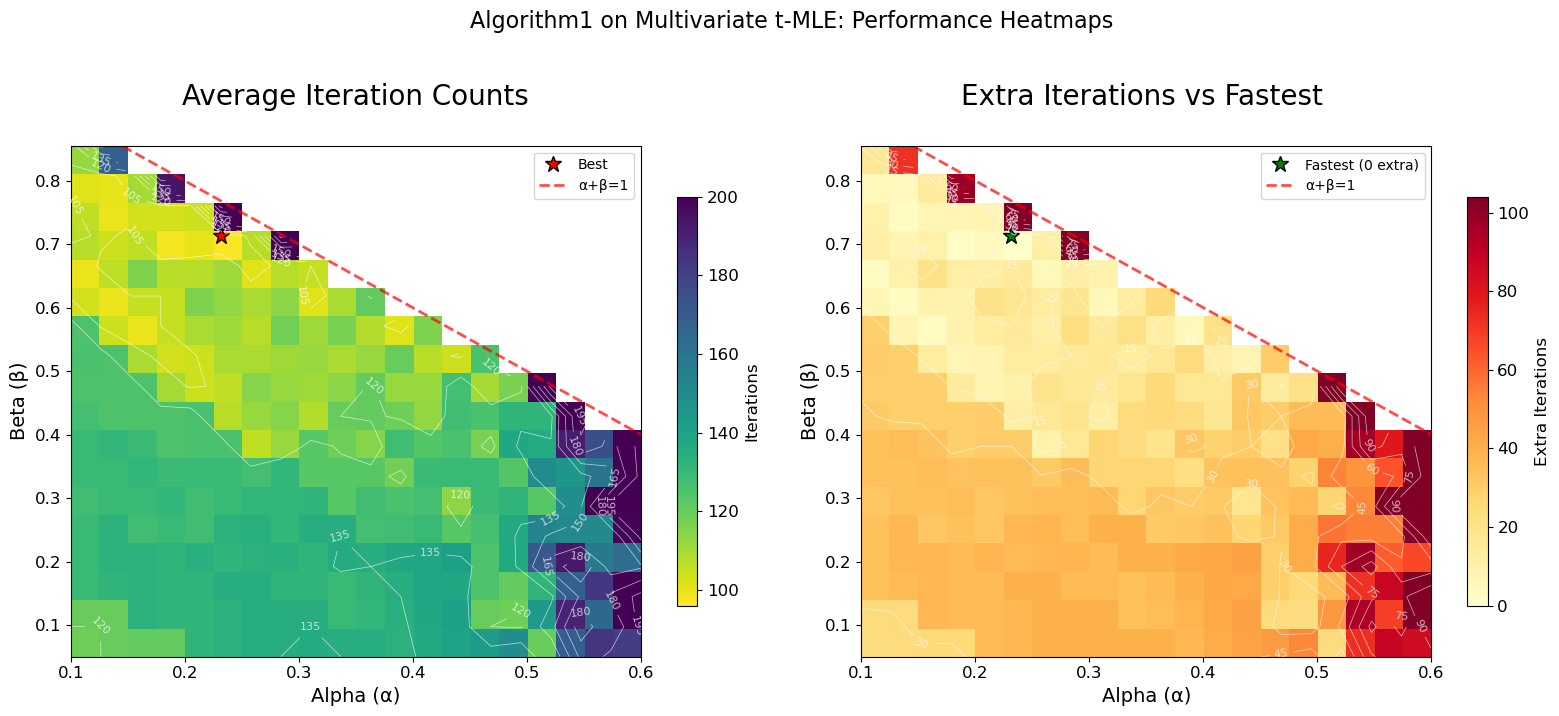


HEATMAP STATISTICS
Grid coverage: 263/360 points (73.1%)

Iteration statistics:
  Min: 96.0
  Max: 200.0
  Mean: 129.4
  Std: 22.9

Best parameter combinations (top 5):
  #1: α=0.311, β=0.618, α+β=0.929, iter=101.0
  #2: α=0.258, β=0.618, α+β=0.876, iter=109.0
  #3: α=0.468, β=0.571, α+β=1.039, iter=nan
  #4: α=0.205, β=0.571, α+β=0.776, iter=109.0
  #5: α=0.416, β=0.524, α+β=0.939, iter=107.0

Analysis completed successfully!


In [25]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D

class UniformAlphaBetaMultivariateTTest:
    """对alpha和beta都均匀采样，测试多元t分布MLE的性能"""
    
    def __init__(self, dim=10, n_samples=1000, df_true=5.0, max_iter=100, n_runs=3):
        """
        Args:
            dim: 数据维度
            n_samples: 样本数量
            df_true: 真实自由度
            max_iter: 最大迭代次数
            n_runs: 每个配置的运行次数
        """
        self.dim = dim
        self.n_samples = n_samples
        self.df_true = df_true
        self.max_iter = max_iter
        self.n_runs = n_runs
        self.results = {}
        
        # 设置字体
        plt.rcParams.update({
            'font.size': 12,
            'axes.labelsize': 14,
            'xtick.labelsize': 12,
            'ytick.labelsize': 12,
            'legend.fontsize': 10,
        })
    
    def create_uniform_alpha_beta_grid(self, alpha_density=10, beta_density=10):
        """
        在alpha+beta<1的区域内对alpha和beta都进行均匀采样
        """
        print(f"Creating uniform grid in α+β<1 region...")
        
        # 参数范围
        alpha_min, alpha_max = 0.1, 0.6
        beta_min, beta_max = 0.05, 0.95
        
        # 创建网格
        alphas = np.linspace(alpha_min, alpha_max, alpha_density)
        betas = np.linspace(beta_min, beta_max, beta_density)
        
        param_combinations = []
        total_possible = len(alphas) * len(betas)
        valid_count = 0
        
        for i, alpha in enumerate(alphas):
            for j, beta in enumerate(betas):
                if alpha + beta < 1.0:  # 严格小于1
                    sum_ab = alpha + beta
                    distance_to_one = 1.0 - sum_ab
                    
                    param_combinations.append({
                        'alpha': float(alpha),
                        'beta': float(beta),
                        'alpha_beta_sum': float(sum_ab),
                        'distance_to_one': float(distance_to_one),
                        'name': f'α={alpha:.3f}_β={beta:.3f}_sum={sum_ab:.4f}'
                    })
                    valid_count += 1
        
        print(f"Uniform grid: {valid_count}/{total_possible} valid points ({valid_count/total_possible*100:.1f}%)")
        
        return param_combinations
    
    def run_single_test(self, alpha, beta):
        """运行单次测试"""
        # 创建Algorithm1优化器
        optimizer = Algorithm1(alpha=alpha, beta=beta)
        optimizer.name = f"α={alpha:.3f}_β={beta:.3f}"
        
        # 创建多元t分布MLE问题
        model = MultivariateTMLE(
            n_samples=self.n_samples, 
            dim=self.dim, 
            df_true=self.df_true
        )
        
        # 获取初始猜测
        initial_theta = model.get_initial_guess()
        param_count = model.get_parameter_count()
        
        # 运行优化
        theta_opt = optimizer.optimize(
            model, 
            param_count,
            initial_theta=initial_theta,
            max_iter=self.max_iter,
            tol=1e-6
        )
        
        # 评估估计质量
        estimation_quality = model.evaluate_estimation(theta_opt)
        
        return {
            'history': optimizer.history.copy(),
            'estimation_quality': estimation_quality,
            'final_theta': theta_opt,
            'final_loss': optimizer.history['loss'][-1] if optimizer.history['loss'] else float('inf'),
            'final_grad_norm': optimizer.history['grad_norm'][-1] if optimizer.history['grad_norm'] else float('inf')
        }
    
    def run_uniform_grid_test(self, alpha_density=10, beta_density=10):
        """运行均匀网格测试"""
        print(f"\nRunning Multivariate t-distribution MLE tests")
        print(f"  Uniform grid: α×β = {alpha_density}×{beta_density}")
        print(f"  Dimension: {self.dim}, Samples: {self.n_samples}")
        print(f"  True df: {self.df_true}, Max iterations: {self.max_iter}")
        print(f"  Runs per config: {self.n_runs}")
        
        # 创建参数网格
        param_grid = self.create_uniform_alpha_beta_grid(alpha_density, beta_density)
        
        self.results = {}
        total_configs = len(param_grid)
        total_runs = total_configs * self.n_runs
        
        print(f"\nTotal: {total_configs} parameter combinations × {self.n_runs} runs = {total_runs} tests")
        
        start_time = time.time()
        
        # 使用进度条
        with tqdm(total=total_configs, desc="Testing configurations", unit="config") as pbar:
            for config_idx, params in enumerate(param_grid):
                alpha = params['alpha']
                beta = params['beta']
                sum_ab = params['alpha_beta_sum']
                
                # 运行多次
                all_iterations = []
                all_final_losses = []
                
                # 内部运行进度条（可选，如果不想太详细可以去掉）
                for run_idx in range(self.n_runs):
                    result = self.run_single_test(alpha, beta)
                    
                    # 获取迭代次数
                    if result['history'].get('loss'):
                        iterations = len(result['history']['loss'])
                    else:
                        iterations = self.max_iter
                    
                    all_iterations.append(iterations)
                    all_final_losses.append(result['final_loss'])
                
                # 计算统计量
                valid_iterations = [it for it in all_iterations if it < self.max_iter]
                avg_iterations = np.mean(valid_iterations) if valid_iterations else self.max_iter
                iterations_std = np.std(valid_iterations) if len(valid_iterations) > 1 else 0
                
                # 保存结果
                self.results[params['name']] = {
                    'alpha': alpha,
                    'beta': beta,
                    'alpha_beta_sum': sum_ab,
                    'distance_to_one': params['distance_to_one'],
                    'avg_iterations': avg_iterations,
                    'iterations_std': iterations_std,
                    'avg_final_loss': np.mean(all_final_losses),
                    'all_iterations': all_iterations,
                    'all_final_losses': all_final_losses
                }
                
                # 更新进度条，添加额外信息
                pbar.set_postfix({
                    'alpha': f'{alpha:.3f}',
                    'beta': f'{beta:.3f}',
                    'iter': f'{avg_iterations:.1f}'
                })
                pbar.update(1)
        
        # 总体统计
        total_time = time.time() - start_time
        print(f"\nTest completed in {total_time:.1f}s")
        print(f"Average time per configuration: {total_time/total_configs:.2f}s")
        
        return self.results
    
    def print_results_summary(self):
        """打印结果摘要"""
        if not self.results:
            print("No results to display.")
            return
        
        print("\n" + "="*80)
        print("RESULTS SUMMARY")
        print("="*80)
        
        # 基本统计
        all_avg_iterations = [r['avg_iterations'] for r in self.results.values()]
        all_alphas = [r['alpha'] for r in self.results.values()]
        all_betas = [r['beta'] for r in self.results.values()]
        all_sums = [r['alpha_beta_sum'] for r in self.results.values()]
        
        print(f"Total configurations: {len(self.results)}")
        print(f"Alpha range: [{min(all_alphas):.3f}, {max(all_alphas):.3f}]")
        print(f"Beta range: [{min(all_betas):.3f}, {max(all_betas):.3f}]")
        print(f"Alpha+beta range: [{min(all_sums):.4f}, {max(all_sums):.4f}]")
        print(f"\nIteration statistics:")
        print(f"  Min: {np.min(all_avg_iterations):.1f}")
        print(f"  Max: {np.max(all_avg_iterations):.1f}")
        print(f"  Mean: {np.mean(all_avg_iterations):.1f}")
        print(f"  Std: {np.std(all_avg_iterations):.1f}")
        
        # 按区域分析
        print(f"\nPerformance by α+β region:")
        sum_bins = [0.5, 0.7, 0.9, 1.0]
        for i in range(len(sum_bins)-1):
            lower = sum_bins[i]
            upper = sum_bins[i+1]
            
            region_results = [r for r in self.results.values() if lower <= r['alpha_beta_sum'] < upper]
            if region_results:
                region_iters = [r['avg_iterations'] for r in region_results]
                print(f"  α+β ∈ [{lower:.1f}, {upper:.1f}): {len(region_results)} points, "
                      f"avg iter={np.mean(region_iters):.1f}")
        
        # 最佳配置
        best_config = min(self.results.values(), key=lambda x: x['avg_iterations'])
        worst_config = max(self.results.values(), key=lambda x: x['avg_iterations'])
        
        print(f"\nBest configuration:")
        print(f"  α={best_config['alpha']:.3f}, β={best_config['beta']:.3f}, "
              f"α+β={best_config['alpha_beta_sum']:.4f}")
        print(f"  Avg iterations: {best_config['avg_iterations']:.1f} ± {best_config['iterations_std']:.1f}")
        
        print(f"\nWorst configuration:")
        print(f"  α={worst_config['alpha']:.3f}, β={worst_config['beta']:.3f}, "
              f"α+β={worst_config['alpha_beta_sum']:.4f}")
        print(f"  Avg iterations: {worst_config['avg_iterations']:.1f} ± {worst_config['iterations_std']:.1f}")
    
    def plot_heatmaps(self):
        """绘制两个热力图"""
        if not self.results:
            print("No results to plot.")
            return
        
        print("\nGenerating heatmaps...")
        
        # 提取数据
        alphas = []
        betas = []
        avg_iterations = []
        
        for name, result in self.results.items():
            alphas.append(result['alpha'])
            betas.append(result['beta'])
            avg_iterations.append(result['avg_iterations'])
        
        if not alphas:
            print("No valid data.")
            return
        
        # 创建唯一值列表
        unique_alphas = sorted(set(alphas))
        unique_betas = sorted(set(betas))
        
        # 创建网格矩阵
        Z_iter = np.full((len(unique_betas), len(unique_alphas)), np.nan)
        
        # 填充迭代次数数据
        for alpha_val, beta_val, avg_iter in zip(alphas, betas, avg_iterations):
            alpha_idx = unique_alphas.index(alpha_val)
            beta_idx = unique_betas.index(beta_val)
            Z_iter[beta_idx, alpha_idx] = avg_iter
        
        # 创建图形
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        fig.suptitle(f'Algorithm1 on Multivariate t-MLE: Performance Heatmaps', 
                    fontsize=16, y=1.02)
        
        # 1. 迭代次数热力图
        ax1 = axes[0]
        
        if np.any(~np.isnan(Z_iter)):
            # 绘制热力图
            im1 = ax1.imshow(Z_iter, aspect='auto', origin='lower',
                           extent=[min(unique_alphas), max(unique_alphas), 
                                   min(unique_betas), max(unique_betas)],
                           cmap='viridis_r')  # 反转viridis，蓝色表示少迭代
            
            # 添加等高线
            X, Y = np.meshgrid(unique_alphas, unique_betas)
            contour1 = ax1.contour(X, Y, Z_iter, colors='white', 
                                  linewidths=0.5, alpha=0.7)
            ax1.clabel(contour1, contour1.levels, inline=True, fontsize=8, fmt='%.0f')
            
            # 标记最佳配置
            best_idx = np.argmin(avg_iterations)
            best_alpha = alphas[best_idx]
            best_beta = betas[best_idx]
            
            alpha_idx = unique_alphas.index(best_alpha)
            beta_idx = unique_betas.index(best_beta)
            
            ax1.plot(best_alpha, best_beta, 'r*', markersize=12, 
                    markeredgecolor='black', label='Best')
            
            # 添加α+β=1的线
            x_line = np.linspace(min(unique_alphas), max(unique_alphas), 100)
            y_line = 1.0 - x_line
            valid_idx = (y_line >= min(unique_betas)) & (y_line <= max(unique_betas))
            
            if np.any(valid_idx):
                ax1.plot(x_line[valid_idx], y_line[valid_idx], 'r--', 
                        linewidth=2, alpha=0.7, label='α+β=1')
            
            ax1.set_xlabel('Alpha (α)', fontsize=14)
            ax1.set_ylabel('Beta (β)', fontsize=14)
            ax1.set_title('Average Iteration Counts\n')
            ax1.legend(loc='upper right')
            
            # 添加颜色条
            cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.8)
            cbar1.set_label('Iterations', fontsize=12)
        else:
            ax1.text(0.5, 0.5, 'No data available', ha='center', va='center')
            ax1.set_xlabel('Alpha (α)')
            ax1.set_ylabel('Beta (β)')
            ax1.set_title('Average Iteration Counts')
        
        # 2. 额外迭代次数热力图（相对于最快配置）
        ax2 = axes[1]
        
        if np.any(~np.isnan(Z_iter)):
            # 计算最快迭代次数
            fastest_iter = np.nanmin(Z_iter)
            
            # 计算额外迭代次数
            Z_extra = Z_iter - fastest_iter
            Z_extra[Z_extra < 0] = 0  # 确保非负
            
            # 绘制热力图
            im2 = ax2.imshow(Z_extra, aspect='auto', origin='lower',
                           extent=[min(unique_alphas), max(unique_alphas), 
                                   min(unique_betas), max(unique_betas)],
                           cmap='YlOrRd')  # 黄色到红色，表示额外迭代次数
            
            # 添加等高线
            contour2 = ax2.contour(X, Y, Z_extra, colors='white', 
                                  linewidths=0.5, alpha=0.7)
            ax2.clabel(contour2, contour2.levels, inline=True, fontsize=8, fmt='%.0f')
            
            # 标记额外迭代次数为0的点（最快配置）
            zero_indices = np.where(Z_extra == 0)
            if len(zero_indices[0]) > 0:
                for i in range(len(zero_indices[0])):
                    alpha_idx = zero_indices[1][i]
                    beta_idx = zero_indices[0][i]
                    alpha_val = unique_alphas[alpha_idx]
                    beta_val = unique_betas[beta_idx]
                    
                    if i == 0:
                        ax2.plot(alpha_val, beta_val, 'g*', markersize=12, 
                                markeredgecolor='black', label='Fastest (0 extra)')
                    else:
                        ax2.plot(alpha_val, beta_val, 'g*', markersize=12, 
                                markeredgecolor='black')
            
            # 添加α+β=1的线
            if np.any(valid_idx):
                ax2.plot(x_line[valid_idx], y_line[valid_idx], 'r--', 
                        linewidth=2, alpha=0.7, label='α+β=1')
            
            ax2.set_xlabel('Alpha (α)', fontsize=14)
            ax2.set_ylabel('Beta (β)', fontsize=14)
            ax2.set_title(f'Extra Iterations vs Fastest \n')
            ax2.legend(loc='upper right')
            
            # 添加颜色条
            cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.8)
            cbar2.set_label('Extra Iterations', fontsize=12)
        else:
            ax2.text(0.5, 0.5, 'No data available', ha='center', va='center')
            ax2.set_xlabel('Alpha (α)')
            ax2.set_ylabel('Beta (β)')
            ax2.set_title('Extra Iterations vs Fastest')
        
        plt.tight_layout()
        plt.show()
        
        # 热力图统计信息
        self._print_heatmap_stats(unique_alphas, unique_betas, Z_iter)
    
    def _print_heatmap_stats(self, unique_alphas, unique_betas, Z_iter):
        """打印热力图统计信息"""
        print("\n" + "="*60)
        print("HEATMAP STATISTICS")
        print("="*60)
        
        if np.all(np.isnan(Z_iter)):
            print("No valid data in heatmap.")
            return
        
        # 有效数据点
        valid_points = np.sum(~np.isnan(Z_iter))
        total_points = Z_iter.size
        print(f"Grid coverage: {valid_points}/{total_points} points ({valid_points/total_points*100:.1f}%)")
        
        # 迭代次数统计
        valid_iters = Z_iter[~np.isnan(Z_iter)]
        print(f"\nIteration statistics:")
        print(f"  Min: {np.min(valid_iters):.1f}")
        print(f"  Max: {np.max(valid_iters):.1f}")
        print(f"  Mean: {np.mean(valid_iters):.1f}")
        print(f"  Std: {np.std(valid_iters):.1f}")
        
        # 最佳区域分析
        print(f"\nBest parameter combinations (top 5):")
        flat_indices = np.argsort(valid_iters.flatten())
        sorted_iters = valid_iters.flatten()[flat_indices]
        
        # 获取原始坐标
        for i in range(min(5, len(sorted_iters))):
            # 获取原始索引
            orig_idx = flat_indices[i]
            beta_idx, alpha_idx = np.unravel_index(orig_idx, Z_iter.shape)
            
            alpha_val = unique_alphas[alpha_idx]
            beta_val = unique_betas[beta_idx]
            iter_val = Z_iter[beta_idx, alpha_idx]
            sum_val = alpha_val + beta_val
            
            print(f"  #{i+1}: α={alpha_val:.3f}, β={beta_val:.3f}, "
                  f"α+β={sum_val:.3f}, iter={iter_val:.1f}")
    
    def run_comprehensive_analysis(self, alpha_density=10, beta_density=10):
        """运行完整的分析流程"""
        print("="*80)
        print(f"Multivariate t-distribution MLE - Uniform Grid Analysis")
        print(f"Grid: {alpha_density}×{beta_density} points in α+β<1 region")
        print(f"Dimension={self.dim}, Samples={self.n_samples}, df_true={self.df_true}")
        print("="*80)
        
        # 1. 运行测试
        print("\n[1/2] Running tests...")
        self.run_uniform_grid_test(alpha_density, beta_density)
        
        # 2. 打印结果摘要
        print("\n[2/2] Generating results summary and visualizations...")
        self.print_results_summary()
        
        # 3. 绘制热力图（已去掉3D图）
        self.plot_heatmaps()
        
        print("\n" + "="*80)
        print("Analysis completed successfully!")
        print("="*80)


# 使用示例
if __name__ == "__main__":
    # 创建测试器
    tester = UniformAlphaBetaMultivariateTTest(
        dim=5,           # 数据维度
        n_samples=100,   # 样本数量
        df_true=0.5,     # 真实自由度
        max_iter=200,    # 最大迭代次数
        n_runs=10        # 每个配置运行10次
    )
    
    # 运行分析
    tester.run_comprehensive_analysis(
        alpha_density=20,   # alpha采样密度
        beta_density=20    # beta采样密度
    )